# Эксперименты для улучшения качества работы GRU


**Содержание:**
- [Группировка классов](#группировка-классов)
- [Class weights](#cross-entropy--class-weights)
- [Weighted Random Sampler](#sampler)
- [Focal Loss](#focal-loss)
- [Выводы](#выводы-и-наблюдения)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Группировка классов

In [4]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

Исходные классы:

- `0`: Angry
- `1`: Calm
- `2`: Happy
- `3`: Neutral
- `4`: Sad

In [5]:
emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

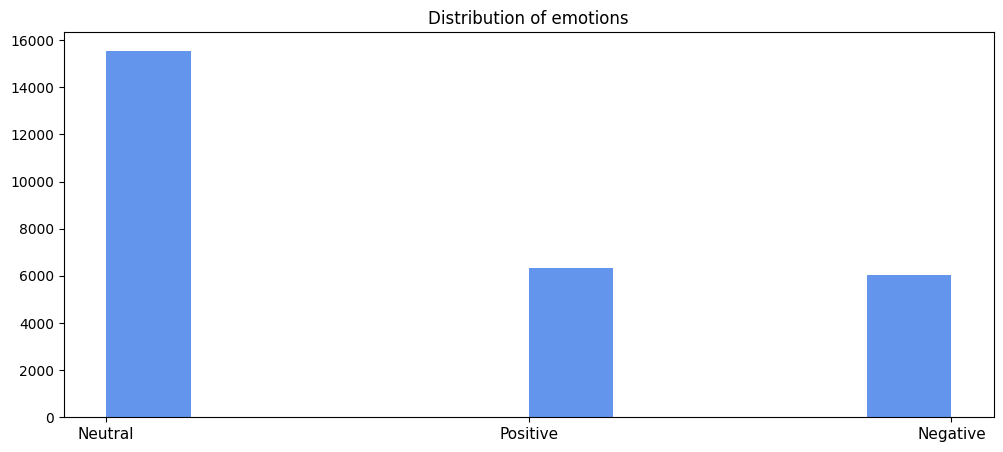

In [6]:
plt.figure(figsize=(12, 5))
plt.title('Distribution of emotions')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2], ['Neutral', 'Positive', 'Negative'],fontsize=11)
plt.show()

In [7]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

In [8]:
test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

In [9]:
feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [10]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

## Cross Entropy + class weights

In [11]:
# вычисляем веса для классов (обратно пропорционально частоте)
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
class_weights

tensor([0.6160, 1.3652, 1.5524])

In [13]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)  
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)   

In [14]:
def model_analysis(model, total_epochs, model_optimizer, criterion, focal_loss = False):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            if focal_loss == True:
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
                loss = criterion(output, y_one_hot)
            else:
                loss = criterion(output, y_batch)
            
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

- Используем параметры, подобранные ранее (в baseline)

In [15]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 3,  num_classes = 3, dropout = 0.227, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.005)
criterion = nn.CrossEntropyLoss(weight = class_weights)

In [16]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 30, optimizer, criterion)

Epoch 1/30, Loss: 1.106555
Epoch 10/30, Loss: 1.014450
Epoch 20/30, Loss: 1.025342
Epoch 30/30, Loss: 0.809370


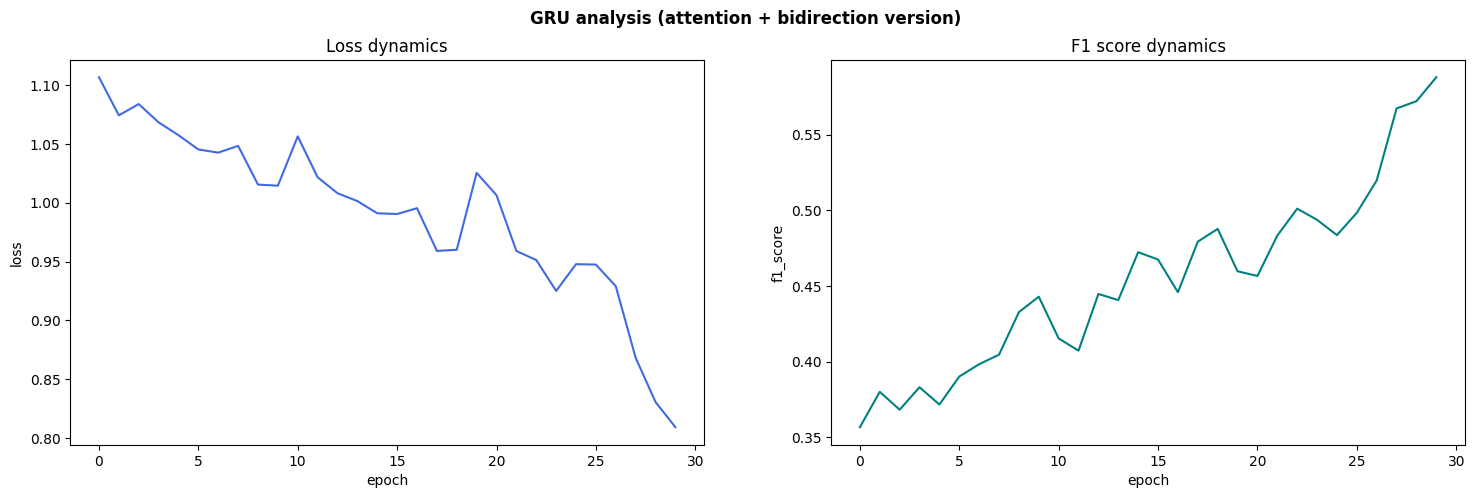

In [17]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

Как можем заметить, улучшения есть, но переобучение очень сильное

- macro F1  : $\quad 0.22 \longrightarrow 0.33 \: \: (+ 11\%)$

In [18]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.45      0.30      0.36        63
    Positive       0.50      0.27      0.35        45
    Negative       0.19      0.52      0.28        25

    accuracy                           0.33       133
   macro avg       0.38      0.36      0.33       133
weighted avg       0.42      0.33      0.34       133



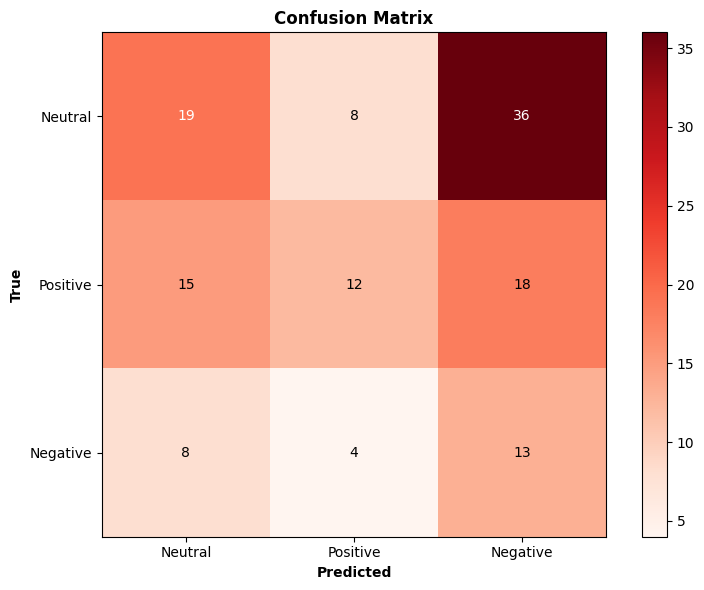

In [19]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

- Модель все еще "боится" ошибаться на редком классе (большая часть предскзаний - негативный класс)
- Позитивный и нейтральный классы плохо распознаются

## Sampler

In [229]:
train_labels = torch.tensor([y for _, y in train_dataset])
class_counts = torch.bincount(train_labels)

# веса для каждого обучающего примера
class_weights = len(train_labels) / (3 * class_counts.float())
sample_weights = class_weights[train_labels] 

In [257]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,  # веса для каждого примера
    num_samples=len(sample_weights),  # сколько примеров выбрать за эпоху
    replacement=True  # можно ли выбирать один пример несколько раз
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    sampler = sampler
)

In [258]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 3,  num_classes = 3, dropout = 0.227, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.005)
criterion = nn.CrossEntropyLoss(weight = class_weights)

In [259]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 30, optimizer, criterion)

Epoch 1/30, Loss: 1.051746
Epoch 10/30, Loss: 0.984440
Epoch 20/30, Loss: 0.834156
Epoch 30/30, Loss: 0.695842


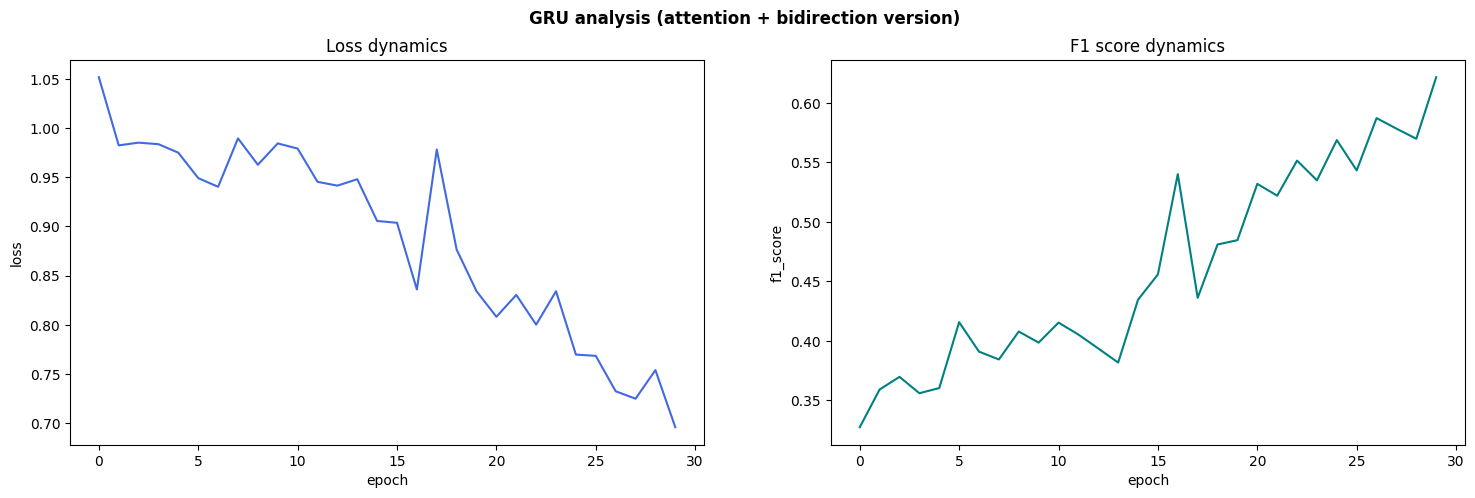

In [260]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

In [265]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.39      0.14      0.21        63
    Positive       0.42      0.24      0.31        45
    Negative       0.17      0.56      0.26        25

    accuracy                           0.26       133
   macro avg       0.33      0.32      0.26       133
weighted avg       0.36      0.26      0.25       133



- Результаты ухудшились 
- Видно сильное переобучение 

## Focal Loss

> Focal Loss —  функция потерь для решения проблемы сильного дисбаланса классов


- Модификация стандартного расчета функции потерь с целью снижения веса простых примеров. Это заставляет алгоритм оптимизации сосредоточить свою обучающую способность на сложных (трудноклассифицируемых) примерах, которые критически важны для производительности модели

- **Идея:** вводится коэффициент $\alpha$, который уменьшает вклад в потери по мере роста уверенности в правильном классе. Веса модели обновляются преимущественно на основе неверно классифицированных образцов или тех, в которых модель не уверена

<img src="https://raw.githubusercontent.com/alinatomilova/Emotion-Detector/main/imgs/focal_loss.jpeg" width="25%"/>

In [266]:
class FocalLoss(nn.Module):
    def __init__(self, alpha = 0.25, gamma = 2.0, reduction = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: [batch_size, num_classes]
        # targets: [batch_size, num_classes] - one-hot encoded
        probs = F.softmax(inputs, dim=1)
        
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # pt - вероятность правильного класса
        pt = torch.sum(probs * targets, dim=1)  
        
        focal_weight = (1 - pt) ** self.gamma
        
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            alpha_t = torch.sum(alpha_t * targets, dim=1) 
            focal_weight = alpha_t * focal_weight
        
        focal_loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [295]:
attn_model_bidirect_f = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 3,  num_classes = 3, dropout = 0.227, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect_f.parameters(), lr = 0.005)
criterion_focal = FocalLoss(alpha=0.75) 

In [296]:
train_loss_attn_bf, train_f1_attn_bf = model_analysis(attn_model_bidirect_f, 30, optimizer, criterion_focal, focal_loss = True)

Epoch 1/30, Loss: 0.354688
Epoch 10/30, Loss: 0.324556
Epoch 20/30, Loss: 0.293720
Epoch 30/30, Loss: 0.255118


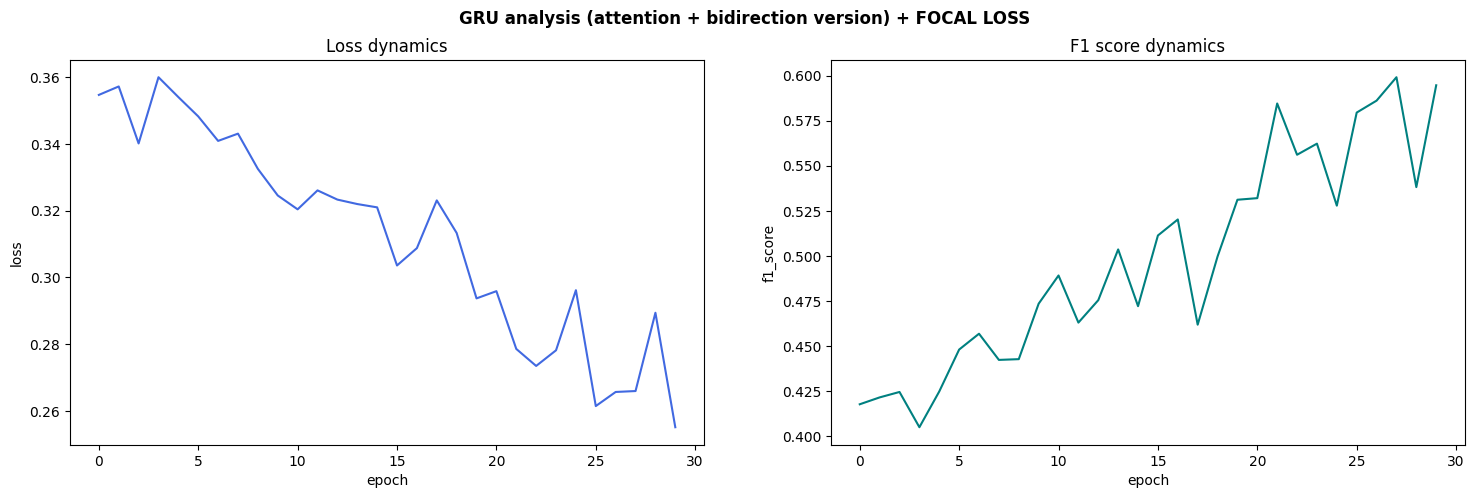

In [297]:
fig = plot_train_dynamics(attn_model_bidirect_f, train_loss_attn_bf, train_f1_attn_bf, 'GRU analysis (attention + bidirection version) + FOCAL LOSS')
plt.show(fig)

In [298]:
pred = attn_model_bidirect_f(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.54      0.48      0.50        63
    Positive       0.53      0.18      0.27        45
    Negative       0.18      0.44      0.25        25

    accuracy                           0.37       133
   macro avg       0.42      0.36      0.34       133
weighted avg       0.47      0.37      0.38       133



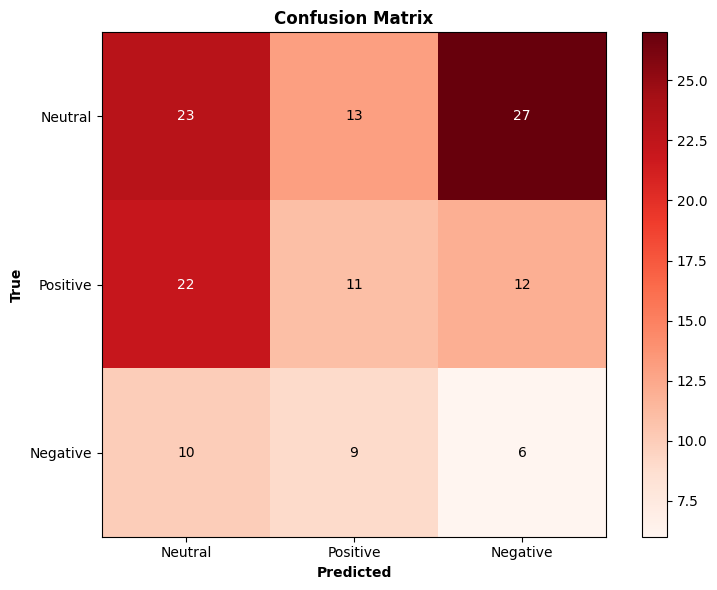

In [ ]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

## Выводы и наблюдения

**Cross Entropy + class weights**
- Модель "боится" ошибаться на редких классах (Negative), поэтому часто жертвует Positive и Neutral ради Negative. Это видно по матрице ошибок

**Sampler**
- Sampler оказался слишком агрессивным для борьбы с дисбалансом классов. Искусственное увеличение количества примеров редкого класса (Negative) путем их повторения заставляет модель "запоминать" эти конкретные примеры, а не обобщать

**Focal Loss**
- Результат обучения с Focal Loss: F1 (macro) = 0.34, Accuracy = 37%. Это лучшая точность, но переобучение все еще сильное
- Решить проблему с редким классом (Negative) не удалось. Вместо самого частого класса модель предсказывает именно Negative, а так же сильно путает Neutral и Positive